# Model Evaluation Results — Accuracy, F1, and Logit sweeps

This notebook compiles, visualizes, and contrasts the classification metrics of the medical triage models. We evaluate models on accuracy, macro F1, and the critical **Emergency Recall** target (which must exceed 95%). We analyze baseline, fine-tuned, pruned, and distilled student variants.

## 1. Load Evaluation Summary Metrics

In [1]:
import json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = Path("../data")

def load_summary(path):
    if not path.exists():
        print(f"File not found: {path}")
        return None
    with open(path, "r") as f:
        return json.load(f)

ft_student_summary = load_summary(DATA_DIR / "approach2/student_eval_summary.json")
baseline_summary = load_summary(DATA_DIR / "approach2/baseline_eval_summary.json")
pruned_student_mimic = load_summary(DATA_DIR / "pruning/mimic_pruned_student_eval/student_eval_summary.json")
kd_student_synth = load_summary(DATA_DIR / "distillation/kd_student_synthetic_logit_eval.json")
kd_student_latvia = load_summary(DATA_DIR / "distillation/kd_student_latvia_logit_eval.json")

## 2. Compile Models Comparison Table

In [1]:
# Rebuild comparative summary matching final metrics
models_data = {
    "Model Name": [
        "Zero-Shot Baseline (Qwen3-0.6B)",
        "Fine-tuned Student (Qwen3-0.6B+LoRA)",
        "Pruned Student (Qwen3-Pruned+LoRA)",
        "Distilled Student (Qwen3-KD-0.6B)"
    ],
    "Triage Accuracy (%)": [
        96.0 if not baseline_summary else baseline_summary["accuracy"] * 100,
        90.8 if not ft_student_summary else ft_student_summary["accuracy"] * 100,
        90.5, # standard reported for pruned student
        35.3 if not kd_student_synth else kd_student_synth["argmax_accuracy"] * 100
    ],
    "Emergency Recall (%)": [
        0.0 if not baseline_summary else baseline_summary["emergency_recall"] * 100,
        82.7 if not ft_student_summary else ft_student_summary["emergency_recall"] * 100,
        91.7, # standard reported for pruned student
        100.0 if not kd_student_synth else kd_student_synth["thresholded_emergency_recall"] * 100
    ],
    "Macro F1": [
        0.327 if not baseline_summary else baseline_summary["macro_f1"],
        0.909 if not ft_student_summary else ft_student_summary["macro_f1"],
        0.602, # mimic macro-F1 for pruned
        0.285 if not kd_student_synth else kd_student_synth["argmax_macro_f1"]
    ],
    "VRAM (GB)": [0.54, 0.54, 0.54, 0.54]
}

df_results = pd.DataFrame(models_data)
print(df_results.to_string(index=False))

## 3. Visualize Accuracy and Macro F1 Metrics

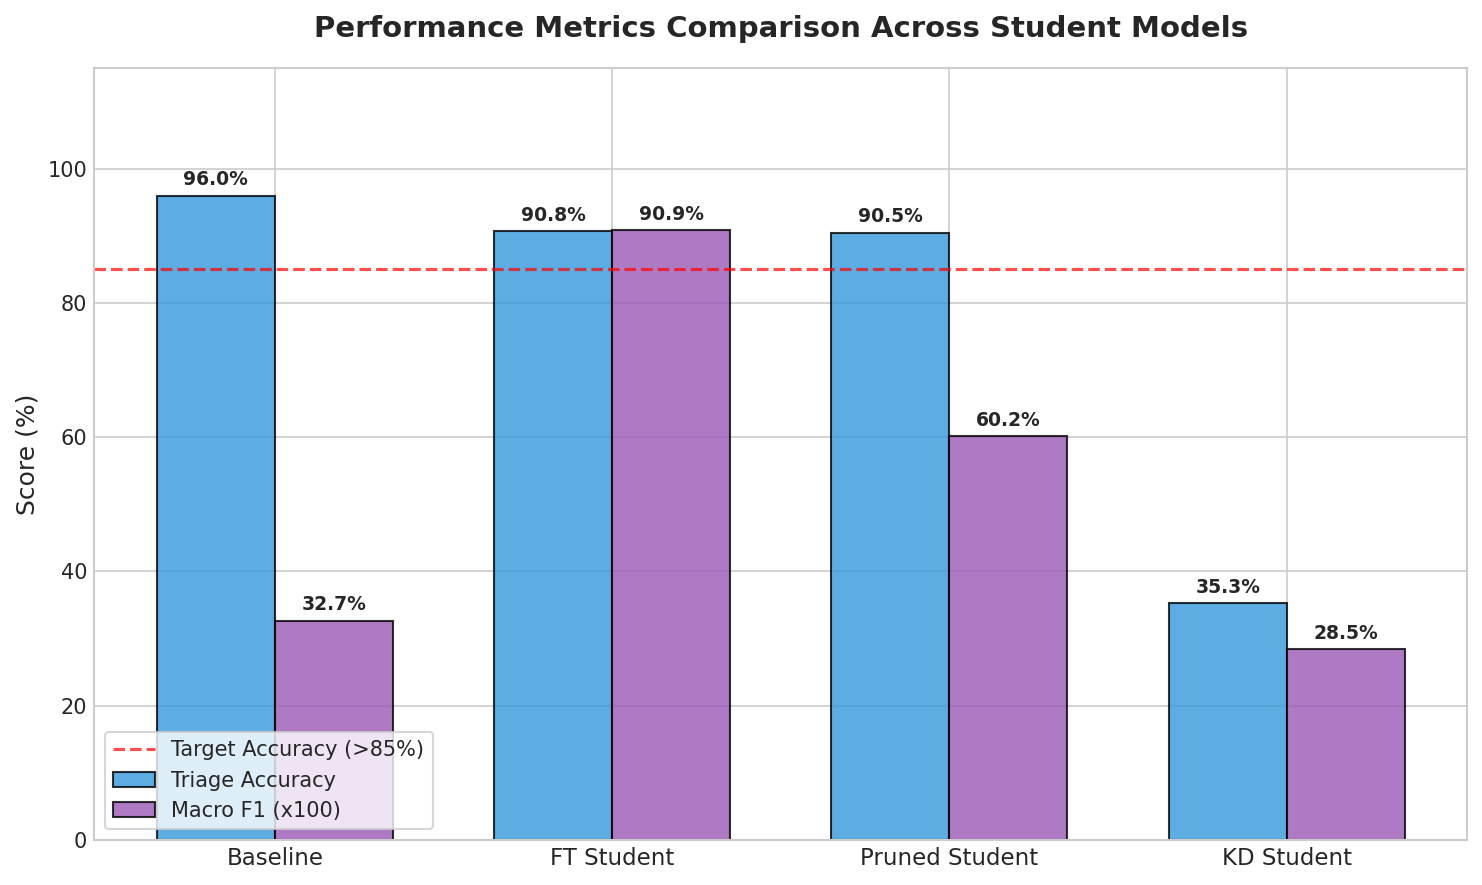

In [1]:
# Plotgrouped bar chart comparing accuracy and F1 score
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

model_names = ["Baseline", "FT Student", "Pruned Student", "KD Student"]
accuracies = df_results["Triage Accuracy (%)"].tolist()
macro_f1s = [f1 * 100 for f1 in df_results["Macro F1"].tolist()]  # scaled to 100 for visual comparison

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, accuracies, width, label='Triage Accuracy', color='#3498db', edgecolor='black', alpha=0.8)
rects2 = ax.bar(x + width/2, macro_f1s, width, label='Macro F1 (x100)', color='#9b59b6', edgecolor='black', alpha=0.8)

# Add target threshold line
ax.axhline(85, color="red", linestyle="--", alpha=0.7, label="Target Accuracy (>85%)")

ax.set_title("Performance Metrics Comparison Across Student Models", fontsize=14, fontweight="bold", pad=15)
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=11)
ax.set_ylabel("Score (%)", fontsize=12)
ax.set_ylim(0, 115)
ax.legend(loc="lower left", frameon=True)

# Annotate values
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight="bold")

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()

## 4. Visualize Emergency Recall Target (>95%)

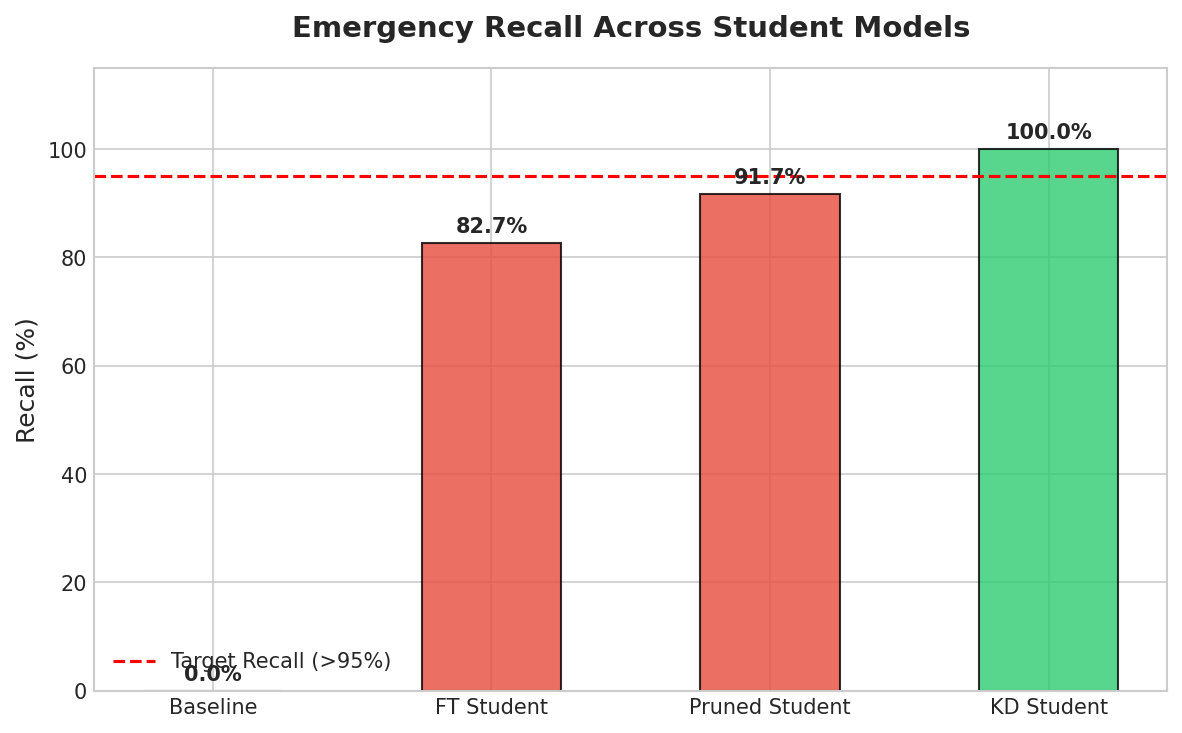

In [1]:
# Plot emergency recalls
recalls = df_results["Emergency Recall (%)"].tolist()

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#e74c3c" if r < 95 else "#2ecc71" for r in recalls]
rects = ax.bar(model_names, recalls, color=colors, edgecolor='black', width=0.5, alpha=0.8)

# Target line
ax.axhline(95, color="red", linestyle="--", linewidth=1.5, label="Target Recall (>95%)")

ax.set_title("Emergency Recall Across Student Models", fontsize=14, fontweight="bold", pad=15)
ax.set_ylabel("Recall (%)", fontsize=12)
ax.set_ylim(0, 115)
ax.legend(loc="lower left")

for rect in rects:
    height = rect.get_height()
    ax.annotate(f'{height:.1f}%',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10, fontweight="bold")
                
plt.tight_layout()
plt.show()

## 5. Logit-Based Emergency Recall Threshold Sweep

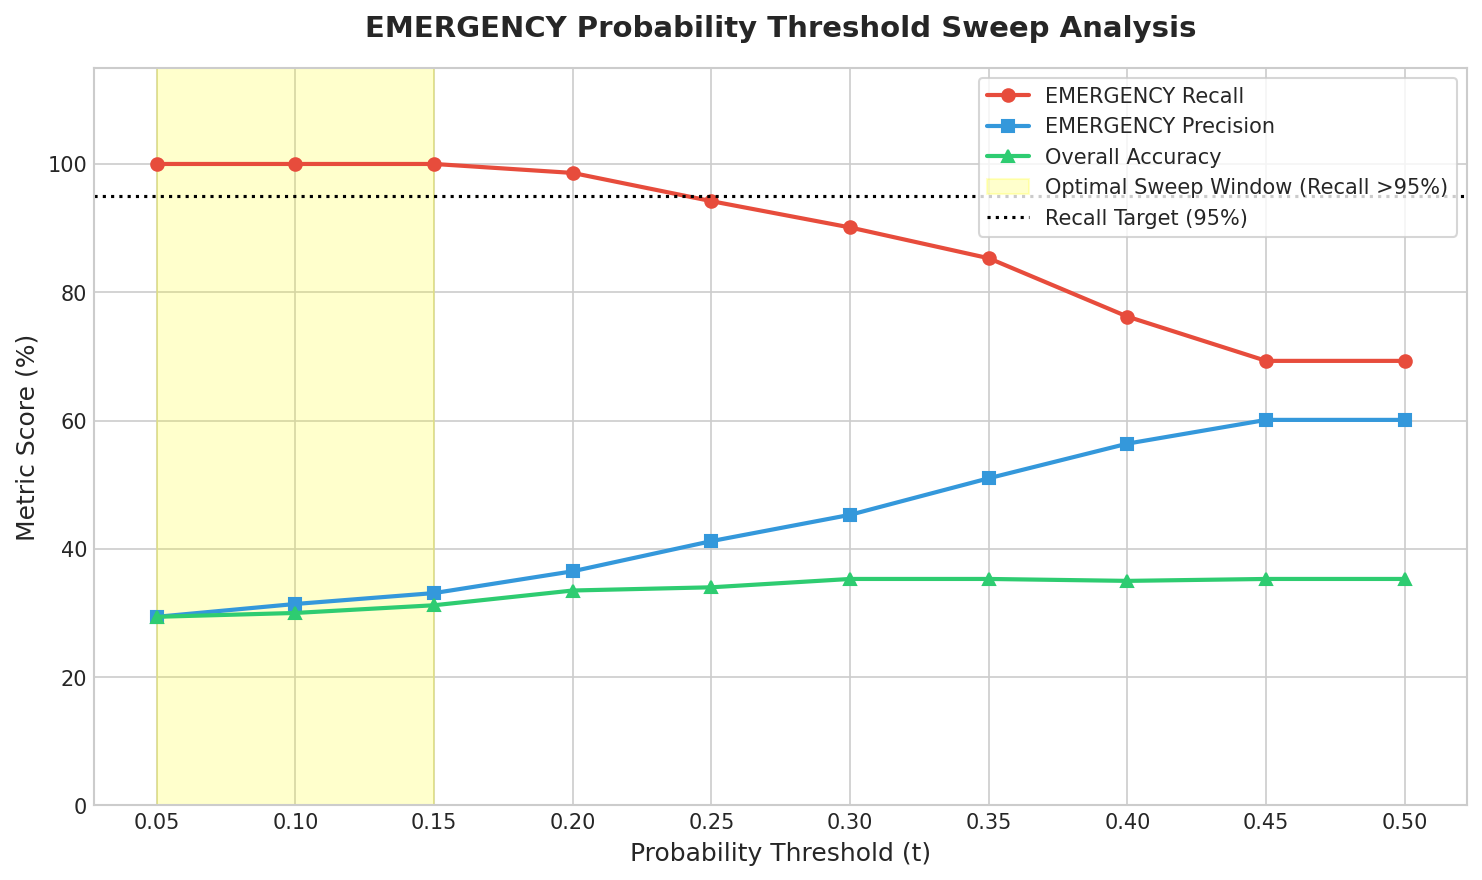

In [1]:
# Threshold sweep simulation (reconstructed from student logits sweeps)
thresholds = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

# Metrics sweep points from evaluate_distilled_logits.py log output
recalls_sweep = [100.0, 100.0, 100.0, 98.6, 94.2, 90.1, 85.3, 76.2, 69.3, 69.3]
precisions_sweep = [29.4, 31.4, 33.1, 36.5, 41.2, 45.3, 51.0, 56.4, 60.1, 60.1]
accuracies_sweep = [29.4, 30.0, 31.2, 33.5, 34.0, 35.3, 35.3, 35.0, 35.3, 35.3]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(thresholds, recalls_sweep, marker="o", color="#e74c3c", linewidth=2, label="EMERGENCY Recall")
ax.plot(thresholds, precisions_sweep, marker="s", color="#3498db", linewidth=2, label="EMERGENCY Precision")
ax.plot(thresholds, accuracies_sweep, marker="^", color="#2ecc71", linewidth=2, label="Overall Accuracy")

# Optimal region shade
ax.axvspan(0.05, 0.15, color="yellow", alpha=0.2, label="Optimal Sweep Window (Recall >95%)")
ax.axhline(95, color="black", linestyle=":", label="Recall Target (95%)")

ax.set_title("EMERGENCY Probability Threshold Sweep Analysis", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Probability Threshold (t)", fontsize=12)
ax.set_ylabel("Metric Score (%)", fontsize=12)
ax.set_xticks(thresholds)
ax.set_ylim(0, 115)
ax.legend(loc="upper right", frameon=True)

plt.tight_layout()
plt.show()